In [67]:
import pandas as pd
import os

import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta

In [68]:
file_path = "realDonaldTrump_truths_2.json"


def load_tweets(file_path):
    # Load JSON into DataFrame
    df = pd.read_json(file_path, lines=True)
    df = df[['created_at', 'content', 'upvotes_count']]
    print(f"Loaded {len(df)} tweets from {file_path}")
    return df

df = load_tweets(file_path)



Loaded 2640 tweets from realDonaldTrump_truths_2.json


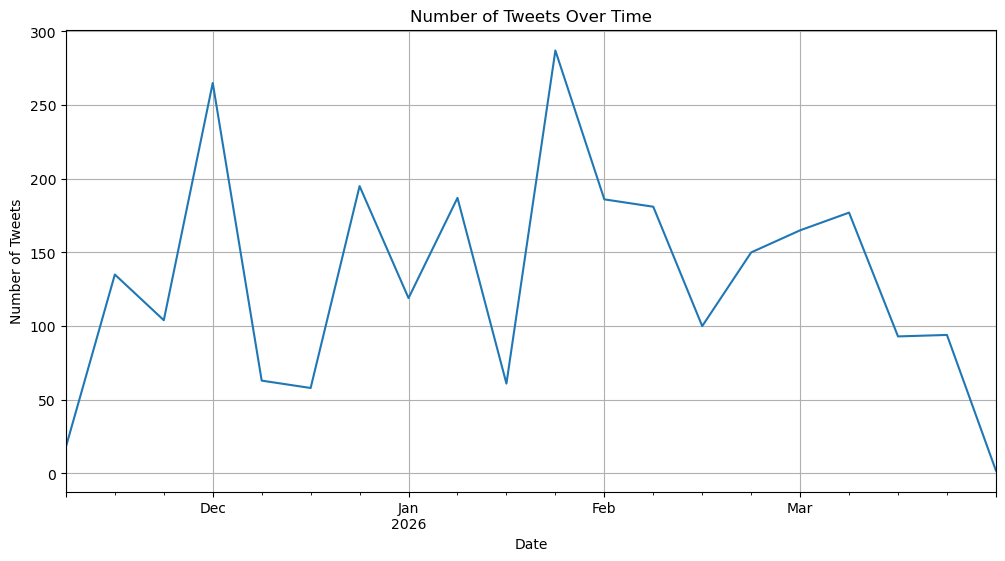

Average number of tweets per day: 20.31


In [69]:
# Show number of tweets as a function of time as a line plot
import matplotlib.pyplot as plt
df['created_at'] = pd.to_datetime(df['created_at'])
df.set_index('created_at', inplace=True)
tweets_per_week = df.resample('W').size()
plt.figure(figsize=(12, 6))
tweets_per_week.plot()
plt.title('Number of Tweets Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Tweets')
plt.grid()
plt.show()

# Print average number of tweets per day
daily_tweets = df.resample('D').size()
average_daily_tweets = daily_tweets.mean()
print(f"Average number of tweets per day: {average_daily_tweets:.2f}")


# Making data ready

In [70]:




df = get_last_n_months_data('SPY', 6)
print(df.tail())

[*********************100%***********************]  1 of 1 completed

          date       price
119 2026-04-02  655.830017
120 2026-04-06  658.929993
121 2026-04-07  659.219971
122 2026-04-08  676.010010
123 2026-04-09  679.909973


In [71]:


def convert_trump_to_daily_tweets(df):
    df['created_at'] = pd.to_datetime(df['created_at'])
    df.set_index('created_at', inplace=True)
    daily_tweets = df.resample('D').size().reset_index(name='tweet_count')
    return daily_tweets

# Clean

In [72]:
import pandas as pd
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download("vader_lexicon")


########### ---------- Helper functions - Trump data ---------- ###########
'''
    Simple loader, where er pick the columns that we want to use
'''
def load_tweets(file_path):
    df = pd.read_json(file_path, lines=True)
    df = df[['created_at', 'content', 'upvotes_count']]
    print(f"Loaded {len(df)} tweets from {file_path}")
    return df


'''
    Ensure we have a datetime time column
'''
def _add_date(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
    df = df.dropna(subset=['created_at'])
    df['date'] = df['created_at'].dt.normalize()
    return df


'''
    Just added a sentiment score as a proof of concept, we should probly make something more cool
'''
def _add_sentiment_feature(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    sia = SentimentIntensityAnalyzer()
    df['sentiment'] = df['content'].fillna('').apply(
        lambda text: sia.polarity_scores(text)['compound']
    )
    return df


'''
    Thought that some keywords might be interesting to track.
'''
def _add_keyword_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    text = df['content'].fillna('').str.lower()

    df['mention_israel'] = text.str.contains(r'\bisrael\b|\bisreal\b', regex=True).astype(int)
    df['mention_greenland'] = text.str.contains(r'\bgreenland\b', regex=True).astype(int)

    return df


'''
    Apply features per tweet, meaning that we still have multiple lines per day
'''
def apply_tweet_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add tweet-level features.
    Easy to extend by adding more `_add_*_feature` functions here.
    """
    df = _add_date(df)
    df = _add_sentiment_feature(df)
    df = _add_keyword_features(df)
    return df

'''
    To match stock data we group the tweets per day.
    Here we decide the aggregation method
'''
def aggregate_tweet_features_daily(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate tweet-level features to one row per day.
    Change mean/sum/count here depending on how you want each feature treated.
    """
    daily_df = (
        df.groupby('date')
        .agg(
            tweet_count=('content', 'count'),
            avg_upvotes=('upvotes_count', 'mean'),
            avg_sentiment=('sentiment', 'mean'),
            mention_israel=('mention_israel', 'max'),
            mention_greenland=('mention_greenland', 'max'),
        )
        .reset_index()
    )

    return daily_df



########### ---------- Helper function - stock data ---------- ###########
"""
Args:
    ticker (str): Ticker symbol (e.g., 'SPY', '^GSPC')
    n_months (int): Number of months of historical data
"""
def get_last_n_months_data(ticker: str, n_months: int) -> pd.DataFrame:
    # Download last n month
    end_date = datetime.today()
    start_date = end_date - pd.DateOffset(months=n_months)

    data = yf.download(ticker, start=start_date, end=end_date)['Close']
    data = data.reset_index()
    data.columns = ['date', 'price']

    return data

########### ---------- Putting it all together ---------- ###########

def get_time_series_data(trump_data_path, ticker, n_months):
    # Load and process Trump tweets
    trump_df = load_tweets(trump_data_path)
    tweet_feature_df = apply_tweet_features(trump_df)
    daily_tweet_df = aggregate_tweet_features_daily(tweet_feature_df)

    # Load stock data
    stock_df = get_last_n_months_data(ticker, n_months)

    # Had some timezone error
    daily_tweet_df['date'] = daily_tweet_df['date'].dt.tz_localize(None)
    stock_df['date'] = stock_df['date'].dt.tz_localize(None)

    merged_df = pd.merge(daily_tweet_df, stock_df, on='date', how='inner')

    return merged_df

df = get_time_series_data(file_path, 'SPY', 6)
print(df)


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/husted42/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Loaded 2640 tweets from realDonaldTrump_truths_2.json


[*********************100%***********************]  1 of 1 completed

         date  tweet_count   avg_upvotes  avg_sentiment  mention_israel  \
0  2025-11-14            2  16480.500000       0.965550               0   
1  2025-11-17           35  10785.342857       0.170080               0   
2  2025-11-18            6  22584.166667       0.491983               0   
3  2025-11-19           17  15647.176471       0.193124               0   
4  2025-11-20           22  14142.363636      -0.089009               0   
..        ...          ...           ...            ...             ...   
81 2026-03-17            6  28257.833333       0.306633               0   
82 2026-03-18           20  20154.500000      -0.049490               0   
83 2026-03-19           19  18378.631579      -0.102179               1   
84 2026-03-20            7  34335.714286       0.334571               1   
85 2026-03-23            2  15955.000000      -0.025050               0   

    mention_greenland       price  
0                   0  668.125671  
1                   0  661.

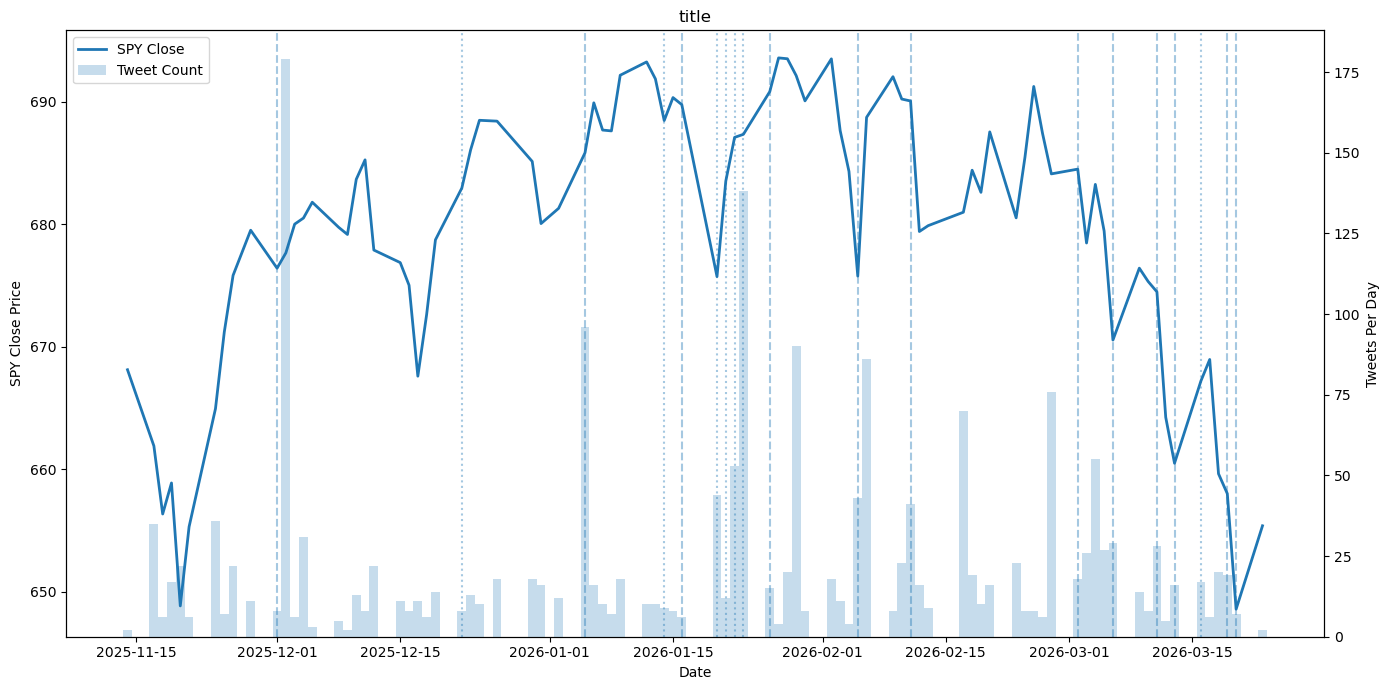

In [73]:
import matplotlib.pyplot as plt
import pandas as pd


plot_df = df.copy()
plot_df["date"] = pd.to_datetime(plot_df["date"])
plot_df = plot_df.sort_values("date")

fig, ax1 = plt.subplots(figsize=(14, 7))

# Price line
ax1.plot(plot_df["date"], plot_df["price"], linewidth=2, label="SPY Close")
ax1.set_xlabel("Date")
ax1.set_ylabel("SPY Close Price")
ax1.set_title("title")

# Tweet count bars on second axis
ax2 = ax1.twinx()
ax2.bar(plot_df["date"], plot_df["tweet_count"], alpha=0.25, width=1.0, label="Tweet Count")
ax2.set_ylabel("Tweets Per Day")

# Keyword event markers
israel_dates = plot_df.loc[plot_df["mention_israel"] == 1, "date"]
greenland_dates = plot_df.loc[plot_df["mention_greenland"] == 1, "date"]

for d in israel_dates:
    ax1.axvline(d, linestyle="--", alpha=0.4)

for d in greenland_dates:
    ax1.axvline(d, linestyle=":", alpha=0.4)

# Simple legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()